# Exercise for Graph V

Your task:
1. Make the graph on the right! You need to implement an Automatic Higher or Lower Game.
2. Set the bounds to between 1 and 20. The graph has to keep guessing (max number of guesses is 7) where if the guess ir correct, then it stops, but if not we keep looping until we hit the max limit of 7.
3. Each time a number is guessed, the hint node should say higher or lower and the graph should account for thi information and guess the next guess accordingly.

Input: {player_name: "David", target_number: 10, guesses: [], attempts: 0, lower_bound: 1, upper_bound: 20}

Hint: It will need to adjust its bounds after every guess based on the hint provided by the hint node.


In [18]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph, END
import random

In [19]:
class AgentState(TypedDict):
    player_name: str
    target_number: int
    guesses: List[int]
    attempts: int
    hint: str
    lower_bound: int
    upper_bound: int

In [36]:
def setup(state: AgentState) -> AgentState:
    """Set up the initial graph state"""
    state["hint"] = ""
    state["attempts"] = 0
    state["guesses"] = []
    state["lower_bound"] = 1
    state["upper_bound"] = 20

    if state["target_number"] > state["upper_bound"] or state["target_number"] < state["lower_bound"]:
        raise ValueError("Target number is out of bounds")

    return state

def guess(state: AgentState) -> AgentState:
    """Generates a random guess number from lower_bound to upper_bound"""
    state["guesses"].append(random.randint(state["lower_bound"], state["upper_bound"]))
    state["attempts"] += 1
    print(f"My guess {state["attempts"]}/7 is {state["guesses"][-1]}")
    return state

def hint(state: AgentState) -> AgentState:
    """Function to decide what to do next"""
    if state["target_number"] == state["guesses"][-1]:
        print(f"Correct! You guessed the number {state["target_number"]} in ", state["attempts"], "/7 attempts.")
        state["hint"] = "Correct"
    elif state["target_number"] > state["guesses"][-1]:
        print(f"Attempt {state["attempts"]}/7: {state["guesses"][-1]} is LOWER! Guessing again.")
        state["hint"] = "Lower"
        state["lower_bound"] = state["guesses"][-1] + 1
    else:
        print(f"Attempt {state["attempts"]}/7: {state["guesses"][-1]} is HIGHER! Guessing again.")
        state["hint"] = "Higher"
        state["upper_bound"] = state["guesses"][-1] - 1

    return state

def should_continue(state: AgentState) -> AgentState:
    if state["hint"] == "Correct" or state["attempts"] >= 7:
        return "exit"
    else:
        return "continue"


In [33]:
# greeting -> random -> random -> random -> random -> random -> END

graph = StateGraph(AgentState)

graph.add_node("setup", setup)
graph.add_node("guess", guess)
graph.add_node("hint_node", hint)

graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint_node")

graph.add_conditional_edges(
    "hint_node",
    should_continue,
    {
        "continue": "guess",
        "exit": END
    }
)

graph.set_entry_point("setup")

app = graph.compile()

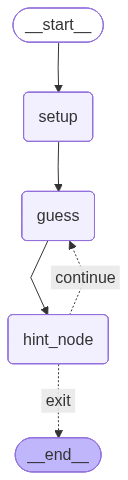

In [34]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [35]:
app.invoke({"player_name": "David", "target_number": 10})

My guess number 1/7 is 19
Attempt 1/7: 19 is HIGHER! Guessing again.
My guess number 2/7 is 14
Attempt 2/7: 14 is HIGHER! Guessing again.
My guess number 3/7 is 5
Attempt 3/7: 5 is LOWER! Guessing again.
My guess number 4/7 is 12
Attempt 4/7: 12 is HIGHER! Guessing again.
My guess number 5/7 is 10
Correct! You guessed the number 10 in  5 /7 attempts.


{'player_name': 'David',
 'target_number': 10,
 'guesses': [19, 14, 5, 12, 10],
 'attempts': 5,
 'hint': 'Correct',
 'lower_bound': 6,
 'upper_bound': 11}